## **Installation des bibliothèques**

In [1]:
%pip install --quiet nltk spacy

## **Load , clean non-words using regular expressions and append the cleaned text to the corpus**

In [2]:
import requests
import re

In [3]:
def load_texts(urls):

    corpus = []

    for url in urls:
        response = requests.get(url)
        response.raise_for_status()

        text = response.text

        # Début et fin du vrai contenu
        start = text.find("START OF")
        end = text.find("END OF")

        if start != -1 and end != -1:
            # Aller à la ligne suivante après "START OF"
            start = text.find("\n", start) + 1
            text = text[start:end]

        # Nettoyage
        text = re.sub(r"[^A-Za-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text)
        text = text.lower().strip()

        corpus.append(text)

    return corpus

In [4]:
urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",      # Alice's Adventures in Wonderland
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",      # Through the Looking-Glass
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt" # A Tangled Tale
]

corpus = load_texts(urls)

print("Nombre de livres :", len(corpus))

Nombre de livres : 3


## **Affichage des caractères**

In [5]:
print(corpus[0][:200])  # Affiche les 200 premiers caractères du premier livre

illustration alice s adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit hole chapter ii the pool of tears chapter iii a caucus race and a long 


In [6]:
print(corpus[1][:200])  # Affiche les 200 premiers caractères du deuxième livre

illustration through the looking glass and what alice found there by lewis carroll the millennium fulcrum edition dramatis person as arranged before commencement of game white red pieces pawns pawns p


In [7]:
print(corpus[2][:200])  # Affiche les 200 premiers caractères du troisième livre

produced by chris curnow carla foust lindy walsh and the online distributed proofreading team at https www pgdp net music transcribed by linda cantoni transcriber s note minor punctuation errors have 


## **Tokenisation**

In [8]:
from nltk.tokenize import word_tokenize

In [9]:
tokenized_corpus = []

for idx, text in enumerate(corpus, start=1):
    tokens = word_tokenize(text, preserve_line=True), #segmentation en phrases puis en tokens
    tokenized_corpus.append(tokens)

    print(f"Livre {idx} - {len(tokens)} tokens")
    print(tokens[:150])
    print()

Livre 1 - 1 tokens
(['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'tea', 'party', 'chapter', 'viii', 'the', 'queen', 's', 'croquet', 'ground', 'chapter', 'ix', 'the', 'mock', 'turtle', 's', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alice', 's', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', 'nothin

## **Stopword**

In [10]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

True

In [11]:
stop_words = set(stopwords.words("english")) # Chargement du langage anglais pour le traitement des stopwords

In [12]:
filtered_tokenized_corpus = [
    [token for token in doc[0] if token not in stop_words]
    for doc in tokenized_corpus
] #Suppression des stopwords du corpus tokenisé

In [13]:
print("Token avant filtrage:", [len(doc) for doc in tokenized_corpus])
print("Token après filtrage :", [len(doc) for doc in filtered_tokenized_corpus])

Token avant filtrage: [1, 1, 1]
Token après filtrage : [12304, 14108, 14052]


In [14]:
sample_stopwords = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves"] #Mots à rechercher dans le corpus filtré pour vérifier leur suppression

for word in sample_stopwords:
    total = sum(doc.count(word) for doc in filtered_tokenized_corpus)
    print(f"'{word}' count after filtering:", total)


'i' count after filtering: 0
'me' count after filtering: 0
'my' count after filtering: 0
'myself' count after filtering: 0
'we' count after filtering: 0
'our' count after filtering: 0
'ours' count after filtering: 0
'ourselves' count after filtering: 0


## **Lemmatisation**

In [15]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
flat_tokens = [token for doc_tuple in tokenized_corpus for token in doc_tuple[0]]
stemmed_first_50 = [stemmer.stem(token) for token in flat_tokens[:50]]

print(stemmed_first_50)

['illustr', 'alic', 's', 'adventur', 'in', 'wonderland', 'by', 'lewi', 'carrol', 'the', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tear', 'chapter', 'iii', 'a', 'caucu', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'send', 'in', 'a', 'littl', 'bill', 'chapter', 'v', 'advic', 'from', 'a', 'caterpillar']


In [16]:
import spacy

In [17]:
# Charger le modèle de langue anglais de spaCy, télécharger s'il n'est pas déjà présent
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")


In [18]:
doc = nlp(corpus[0])
lemmas = [token.lemma_ for token in doc]

print(lemmas[:50])

['illustration', 'alice', 's', 'adventure', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'I', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'send', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar']


In [19]:
# Comparaison entre lemmatisation et racinisation
examples = flat_tokens[:20]
lemmatized = lemmas[:20]
stemmed = [stemmer.stem(tok) for tok in examples]

for token, lemma, stem in zip(examples, lemmatized, stemmed):
    print(f"{token:15} -> lemme: {lemma:15} | stem: {stem}")


illustration    -> lemme: illustration    | stem: illustr
alice           -> lemme: alice           | stem: alic
s               -> lemme: s               | stem: s
adventures      -> lemme: adventure       | stem: adventur
in              -> lemme: in              | stem: in
wonderland      -> lemme: wonderland      | stem: wonderland
by              -> lemme: by              | stem: by
lewis           -> lemme: lewis           | stem: lewi
carroll         -> lemme: carroll         | stem: carrol
the             -> lemme: the             | stem: the
millennium      -> lemme: millennium      | stem: millennium
fulcrum         -> lemme: fulcrum         | stem: fulcrum
edition         -> lemme: edition         | stem: edit
contents        -> lemme: content         | stem: content
chapter         -> lemme: chapter         | stem: chapter
i               -> lemme: I               | stem: i
down            -> lemme: down            | stem: down
the             -> lemme: the             | st

### **Conclusion :**
* La lemmatisation cherche la forme canonique d'un mot en tenant compte de sa catégorie grammaticale et de son sens.
* La racinisation (stemming) applique des règles de transformation plus brutales pour réduire un mot à une racine approximative.
### **Résultat :**
lemmatisation = forme réelle du mot ;  
racinisation = forme simplifiée souvent plus agressive.

## **POS**

In [28]:
import shutil

shutil.rmtree("/root/nltk_data/chunkers", ignore_errors=True)

nltk.download("maxent_ne_chunker", quiet=True)
nltk.download("maxent_ne_chunker_tab",quiet=True)
nltk.download("words",quiet=True)

True

In [29]:
def extract_named_entities(chunked_tree):
    entities = []
    for subtree in chunked_tree:
        if hasattr(subtree, "label") and subtree.label() != "S":
            entity_text = " ".join(token for token, pos in subtree.leaves())
            entities.append((entity_text, subtree.label()))
    return entities


In [30]:
pos_tagged_corpus = [] # Liste pour stocker les tokens avec leurs étiquettes POS
named_entities_corpus = [] # Liste pour stocker les entités nommées

In [31]:

for idx, text in enumerate(corpus, start=1):
    tokens = word_tokenize(text, preserve_line=True)
    tagged = nltk.pos_tag(tokens)
    pos_tagged_corpus.append(tagged)

    ne_tree = nltk.ne_chunk(tagged)
    entities = extract_named_entities(ne_tree)
    named_entities_corpus.append(entities)

    print(f"Livre {idx}: {len(tokens)} tokens, {len(entities)} entités")
    print("Extrait POS :", tagged[:40])
    print("Extrait entités :", entities[:20])
    print()

Livre 1: 27428 tokens, 0 entités
Extrait POS : [('illustration', 'NN'), ('alice', 'NN'), ('s', 'NN'), ('adventures', 'NNS'), ('in', 'IN'), ('wonderland', 'NN'), ('by', 'IN'), ('lewis', 'JJ'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('i', 'VBP'), ('down', 'RP'), ('the', 'DT'), ('rabbit', 'NN'), ('hole', 'JJ'), ('chapter', 'NN'), ('ii', 'VBP'), ('the', 'DT'), ('pool', 'NN'), ('of', 'IN'), ('tears', 'NNS'), ('chapter', 'NN'), ('iii', 'VBP'), ('a', 'DT'), ('caucus', 'NN'), ('race', 'NN'), ('and', 'CC'), ('a', 'DT'), ('long', 'JJ'), ('tale', 'NN'), ('chapter', 'NN'), ('iv', 'VBP'), ('the', 'DT'), ('rabbit', 'NN'), ('sends', 'VBZ')]
Extrait entités : []

Livre 2: 31096 tokens, 0 entités
Extrait POS : [('illustration', 'NN'), ('through', 'IN'), ('the', 'DT'), ('looking', 'VBG'), ('glass', 'NN'), ('and', 'CC'), ('what', 'WP'), ('alice', 'NN'), ('found', 'VBD'), ('there', 'RB'), ('by', 'IN'), ('lewis',

## **Analyse du texte**

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

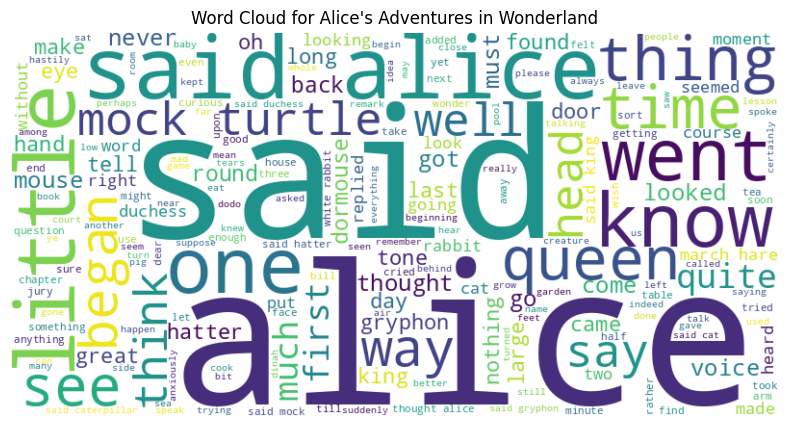

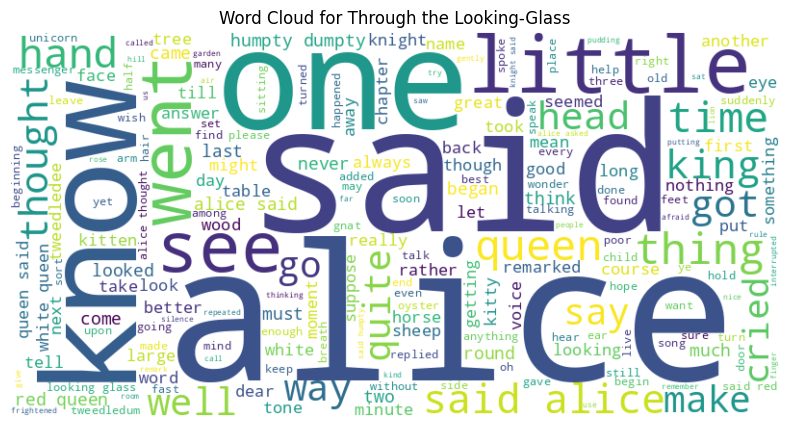

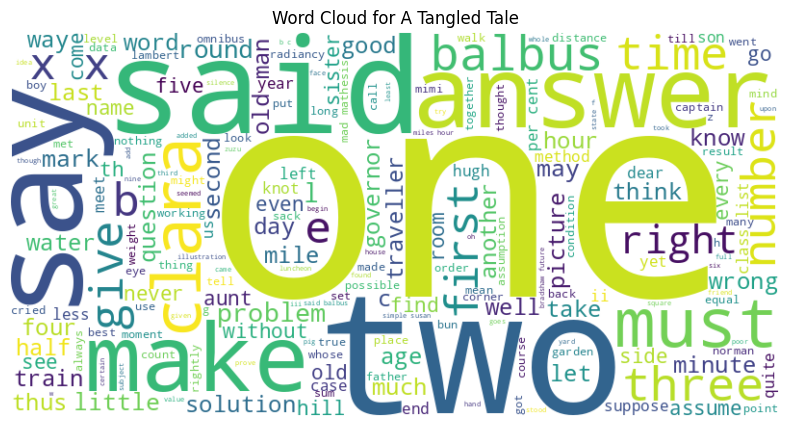

In [35]:

# Create a list of titles for the books, assuming order matches 'corpus'
book_titles = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
] # Nos livres

for idx, doc_tokens in enumerate(filtered_tokenized_corpus):
    text_for_wordcloud = " ".join(doc_tokens)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_wordcloud)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {book_titles[idx]}")
    plt.show()

## **Bow**

In [37]:
from nltk.probability import FreqDist

# Combinez tous les tokens de tous les livres en une seule liste
all_tokens = [token for doc in filtered_tokenized_corpus for token in doc]

# Calculate the frequency distribution of words
fdist = FreqDist(all_tokens) # Calcule la fréquence de chaque mot (le nombre)

top_5_words = fdist.most_common(5) # Les mots qui apparaissent le plus

print("Les cinq mots les plus fréquents dans tous les livres (après suppression des stopwords) :")
for word, frequency in top_5_words:
    print(f"- '{word}': {frequency}")

Les cinq mots les plus fréquents dans tous les livres (après suppression des stopwords) :
- 'said': 1069
- 'alice': 871
- 'one': 466
- 'little': 295
- 'queen': 274


In [39]:
from sklearn.feature_extraction.text import CountVectorizer

In [43]:

# Joindre les tokens de chaque document en une seule chaîne pour CountVectorizer
processed_docs = [" ".join(doc) for doc in filtered_tokenized_corpus]

# Initialiser CountVectorizer
vectorizer = CountVectorizer(min_df=1) ## min_df=1 s'assure que les mots apparaissant dans au moins un document sont inclus

# Adapter le vectoriseur aux documents traités et les transformer
bow_matrix = vectorizer.fit_transform(processed_docs)

# Obtenir les noms des caractéristiques (mots du vocabulaire)
vocabulary = vectorizer.get_feature_names_out()


In [44]:
print("Représentation Bag-of-Words :")

# Parcourir chaque document dans la matrice BoW
for doc_idx, doc_vec in enumerate(bow_matrix):
    print(f"\nDocument {doc_idx + 1} (Livre {book_titles[doc_idx]}):")
    # Parcourir les entrées non nulles du vecteur du document
    # Celles-ci représentent les mots présents dans le document
    for word_idx, count in zip(doc_vec.indices, doc_vec.data):
        word = vocabulary[word_idx]
        print(f"  - Mot: '{word}', Index du mot: {word_idx}, Comptage: {count}")

Représentation Bag-of-Words :

Document 1 (Livre Alice's Adventures in Wonderland):
  - Mot: 'illustration', Index du mot: 2587, Comptage: 1
  - Mot: 'alice', Index du mot: 133, Comptage: 399
  - Mot: 'adventures', Index du mot: 83, Comptage: 7
  - Mot: 'wonderland', Index du mot: 5860, Comptage: 3
  - Mot: 'lewis', Index du mot: 2968, Comptage: 1
  - Mot: 'carroll', Index du mot: 748, Comptage: 1
  - Mot: 'millennium', Index du mot: 3262, Comptage: 1
  - Mot: 'fulcrum', Index du mot: 2127, Comptage: 1
  - Mot: 'edition', Index du mot: 1620, Comptage: 1
  - Mot: 'contents', Index du mot: 1088, Comptage: 1
  - Mot: 'chapter', Index du mot: 806, Comptage: 24
  - Mot: 'rabbit', Index du mot: 4099, Comptage: 53
  - Mot: 'hole', Index du mot: 2491, Comptage: 6
  - Mot: 'ii', Index du mot: 2581, Comptage: 2
  - Mot: 'pool', Index du mot: 3872, Comptage: 12
  - Mot: 'tears', Index du mot: 5180, Comptage: 12
  - Mot: 'iii', Index du mot: 2582, Comptage: 2
  - Mot: 'caucus', Index du mot: 771, 

In [46]:
# Extraire les mots et les fréquences du top 5
words = [item[0] for item in top_5_words]
counts = [item[1] for item in top_5_words]

# Créer les labels pour la légende (mot: fréquence)
legend_labels = [f"{word}: {count}" for word, count in top_5_words]


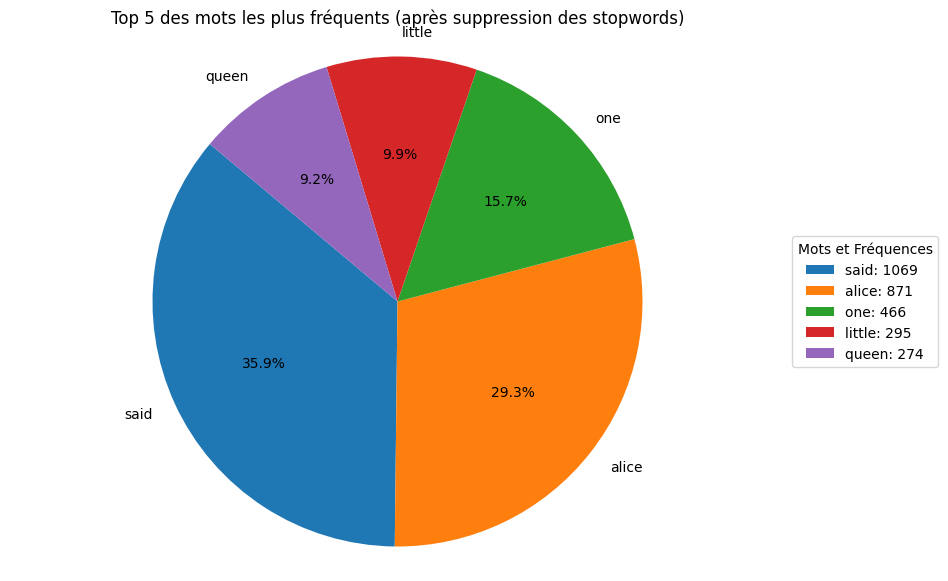

In [47]:
plt.figure(figsize=(10, 7))
plt.pie(counts, labels=words, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 des mots les plus fréquents (après suppression des stopwords)')
plt.legend(legend_labels, title="Mots et Fréquences", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.axis('equal') # Assure que le cercle est parfait.
plt.show()

### **Analyse**

* **'said' (dit)** : Ce mot est très fréquent dans les textes narratifs, en particulier les romans où il y a beaucoup de dialogues. Sa forte présence est donc attendue et pertinente pour le style des livres, même s'il n'est pas "informatif" sur le thème spécifique du livre.
* **'alice'** : C'est le personnage principal de deux des trois livres analysés ("Alice au pays des merveilles" et "De l'autre côté du miroir"). Sa fréquence élevée est très attendue et extrêmement informative, car elle désigne l'héroïne centrale des histoires.
* **'one' (un/une)** : Ce mot est un déterminant ou un pronom commun. Bien qu'il soit fréquent, il est moins informatif sur le contenu thématique que 'alice' ou 'queen'. Il est plus un mot de structure qui a survécu à la suppression des stopwords.
* **'little' (petit)** : Cet adjectif est également pertinent et attendu. Les livres d'Alice mettent souvent en scène de jeunes personnages et des objets ou créatures de petite taille, ou encore des situations où la taille est un thème important. Il est donc pertinent pour décrire l'atmosphère et les éléments des histoires.
* **'queen' (reine)** : Ce mot est très informatif et attendu, car la Reine de Cœur et la Reine Rouge sont des personnages centraux et emblématiques des aventures d'Alice. Sa présence indique clairement l'importance de ces figures dans les récits.

## **TF-IDF**

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [49]:

# Initialize TfidfVectorizer with min_df=1 and max_df=2 as requested
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)

# Fit the vectorizer to the processed documents and transform them
# This creates the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)

# Get the feature names (words in the vocabulary)
tfidf_vocabulary = tfidf_vectorizer.get_feature_names_out()

print("Représentation TF-IDF (Term Frequency-Inverse Document Frequency) :")
# Convertir la matrice TF-IDF en DataFrame pour une meilleure visualisation
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vocabulary)

# Afficher les premières lignes du DataFrame TF-IDF et les noms des documents
display(tfidf_df.head())

Représentation TF-IDF (Term Frequency-Inverse Document Frequency) :


,ab,abandoned,abate,abide,able,abroad,abruptness,absence,absent,absolutely,...,youth,ys,ysmim,zealand,zero,zeroes,zigzag,zimmermann,zo,zuzu
0,0.000000,0.000000,0.000000,0.005992,0.004557,0.000000,0.000000,0.005992,0.000000,0.000000,...,0.027340,0.000000,0.000000,0.005992,0.000000,0.000000,0.005992,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.028535,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.006253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.008898,0.004449,0.004449,0.000000,0.000000,0.004449,0.004449,0.000000,0.004449,0.013347,...,0.020302,0.013347,0.000000,0.000000,0.004449,0.004449,0.000000,0.004449,0.022245,0.062287


In [50]:

# Afficher la forme de la matrice TF-IDF
print(f"Forme de la matrice TF-IDF : {tfidf_matrix.shape}")
print(f"Nombre de mots uniques dans le vocabulaire TF-IDF : {len(tfidf_vocabulary)}")

Forme de la matrice TF-IDF : (3, 5041)
Nombre de mots uniques dans le vocabulaire TF-IDF : 5041


Visualisation des 5 premiers mots TF-IDF pour chaque document :


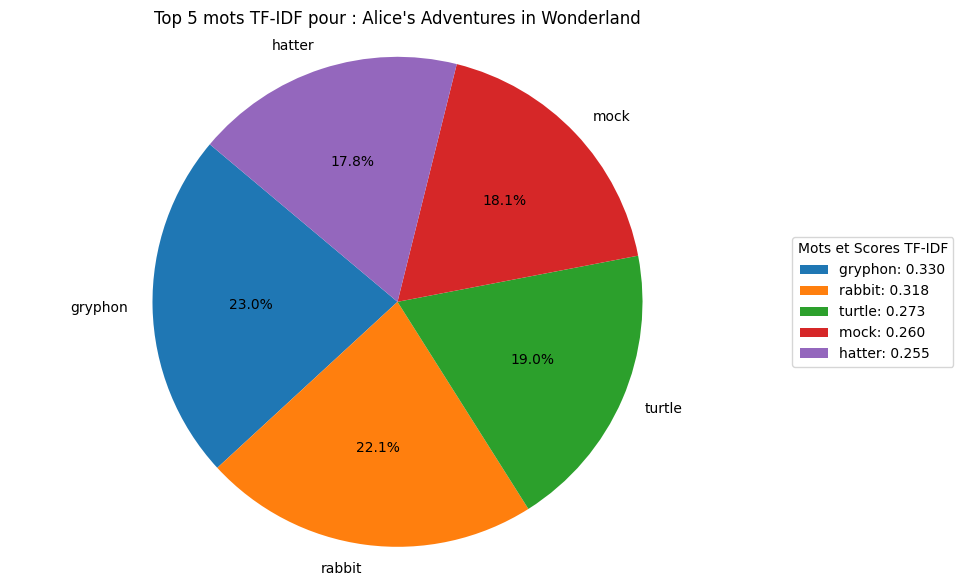

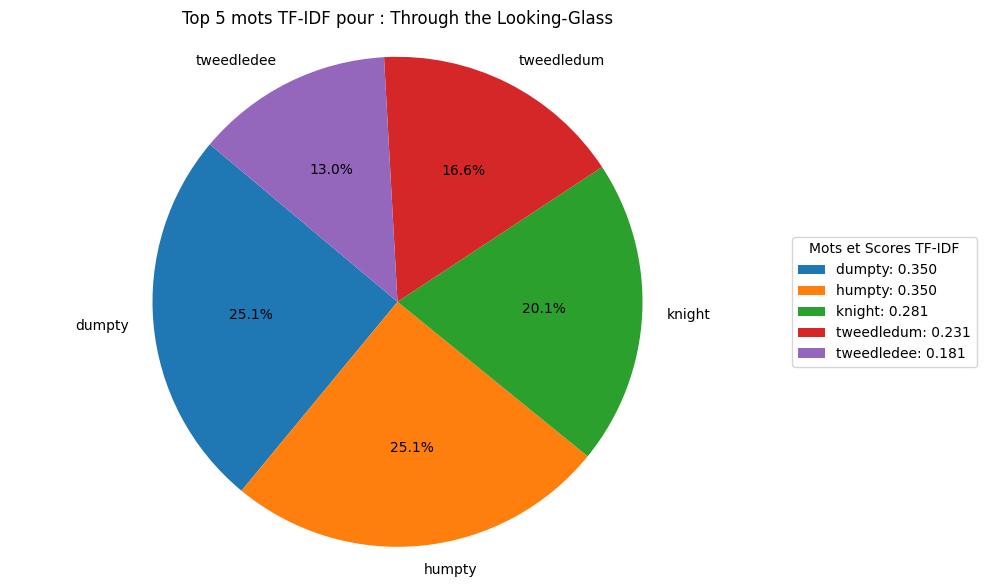

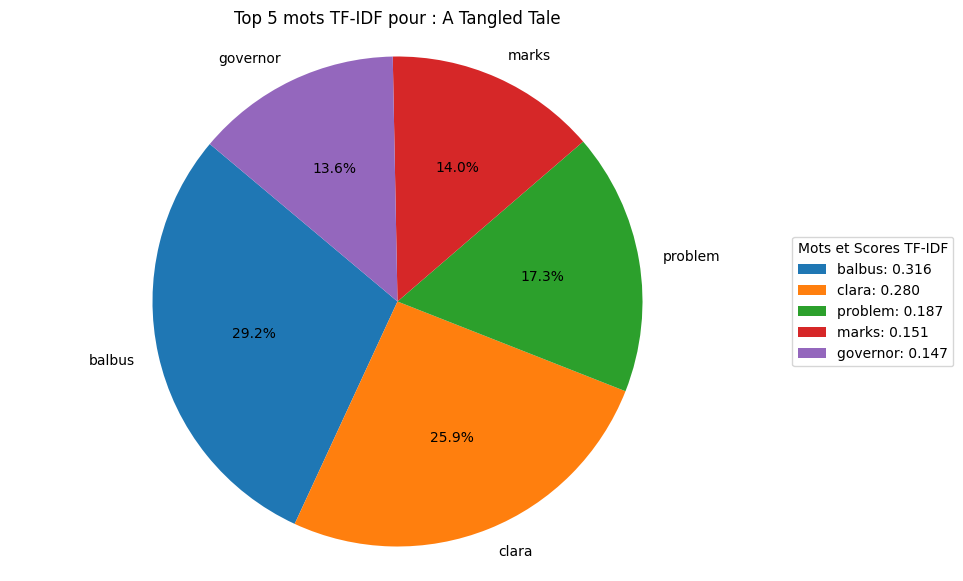

In [51]:
import matplotlib.pyplot as plt

# book_titles is already defined from previous cells
# tfidf_df contains the TF-IDF scores for each document

print("Visualisation des 5 premiers mots TF-IDF pour chaque document :")

for doc_idx, book_title in enumerate(book_titles):
    # Get the TF-IDF scores for the current document
    doc_tfidf_scores = tfidf_df.iloc[doc_idx]

    # Sort the scores in descending order and get the top 5
    top_5_tfidf_words = doc_tfidf_scores.nlargest(5)

    # Extract words and scores for the pie chart
    words = top_5_tfidf_words.index.tolist()
    scores = top_5_tfidf_words.values.tolist()

    # Create labels for the legend (word: score)
    legend_labels = [f"{word}: {score:.3f}" for word, score in zip(words, scores)]

    # Create the pie chart
    plt.figure(figsize=(10, 7))
    plt.pie(scores, labels=words, autopct='%1.1f%%', startangle=140)
    plt.title(f"Top 5 mots TF-IDF pour : {book_title}")
    plt.legend(legend_labels, title="Mots et Scores TF-IDF", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.axis('equal') # Ensure the pie chart is circular
    plt.show()
    print() # Add a newline for better separation between plots